In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
data = yf.download(tickers="^SPX", period="max")
data = data["Close"]

C:\Users\bump1\AppData\Local\Temp\ipykernel_17860\1596001764.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers="^SPX", period="max")
[*********************100%***********************]  1 of 1 completed


In [3]:
from src import BullSpreadClass
cppi = BullSpreadClass.SingleAssetCPPI(data, "2000/1/4", "2025/10/15")
obpi = BullSpreadClass.SingleAssetOBPI(data, "2000/1/4", "2025/10/15")
bull_spread = BullSpreadClass.SingleAssetBullSpread(data, "2000/1/4", "2025/10/15")


c:\Users\bump1\MyFolder\strategy\BullSpreadStrategy\src\BullSpreadClass.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.raw = 10000 * data[self.start_idx:self.end_idx+1].values.T[0] / data.loc[start_date][0]
c:\Users\bump1\MyFolder\strategy\BullSpreadStrategy\src\BullSpreadClass.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.raw = 10000 * data[self.start_idx:self.end_idx+1].values.T[0] / data.loc[start_date][0]
c:\Users\bump1\MyFolder\strategy\BullSpreadStrategy\src\BullSpreadClass.py:234: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer key

In [4]:
c_price, c_volatility, c_floor, c_ratio, c_raw = cppi.run(DEPTH=0.20, PARAM=1, vol_method="exp")
o_price, o_volatility, o_floor, o_ratio, o_raw = obpi.run(DEPTH=0.20, PARAM=1, vol_method="exp")
b_price, b_volatility, b_floor, b_ratio, b_raw = bull_spread.run(FLOORDEPTH=0.20, CAPDEPTH=0.20, PARAM=1, vol_method="exp", strategy='integration')


In [7]:
print(BullSpreadClass.get_performance(c_price))
print(BullSpreadClass.get_performance(o_price))
print(BullSpreadClass.get_performance(b_price))

(np.float64(0.05307346082181), np.float64(0.11224920546538923), np.float64(0.47281814246938786), np.float64(0.17921978273736494))
(np.float64(0.032332457857580404), np.float64(0.06975662987037569), np.float64(0.4635037259922355), np.float64(0.13753337672497035))
(np.float64(0.017236390081613023), np.float64(0.03205281952539555), np.float64(0.5377495751335254), np.float64(0.0827149498598424))


Text(0.5, 1.0, 'volatility')

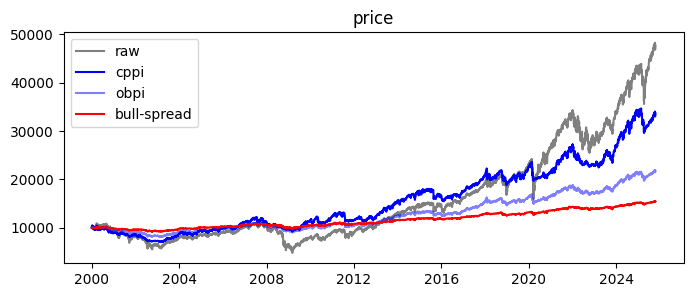

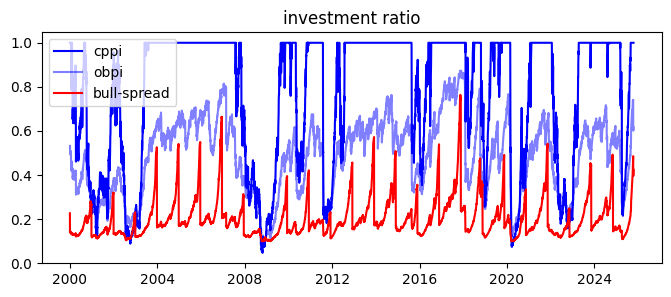

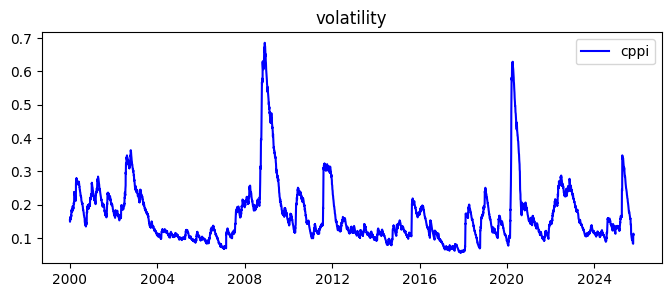

In [8]:
days = cppi.date

plt.figure(figsize=(8,3))
plt.plot(days, c_raw, label='raw', color="gray")
plt.plot(days, c_price, label='cppi', color="blue")
plt.plot(days, o_price, label='obpi', color="blue", alpha=0.5)
plt.plot(days, b_price, label='bull-spread', color="red")
# plt.plot(days, c_floor, label='floor', color="black")
# plt.plot(days, c_floor/(1-0.15), label='M', color="black")
plt.legend()
plt.title("price")

plt.figure(figsize=(8,3))
plt.plot(days, c_ratio, label='cppi', color="blue")
plt.plot(days, o_ratio, label='obpi', color="blue", alpha=0.5)
plt.plot(days, b_ratio, label='bull-spread', color="red")
plt.legend()
plt.title("investment ratio")

plt.figure(figsize=(8,3))
plt.plot(days, c_volatility, label='cppi', color="blue")
plt.legend()
plt.title("volatility")